# Visualizing and the merged datasets to draw conclusions before model training

In [2]:
%%capture
import matplotlib.pyplot as plt
%pip install seaborn
import seaborn as sns
import pandas as pd
%pip install wordcloud
from wordcloud import WordCloud

In [10]:
data = pd.read_csv('data/merged_data.csv')  # Assume csvread is a function to read CSV files
data.head()

,date,summary,volume,pct_change,target
0,2017-12-19,france save marquis de sade 120 day sodom auct...,3.407680e+09,-0.003230,0.0
1,2017-12-20,hedge fund fail stop billiondollar brain city ...,3.246230e+09,-0.000828,1.0
2,2017-12-21,guardian brexit watch brexit helped push down ...,3.293130e+09,0.001986,0.0
3,2017-12-22,steelworker face huge pension cut tata complet...,2.401030e+09,-0.000458,0.0
4,2017-12-26,cramer say owning many stock little cash set u...,1.970660e+09,-0.001058,1.0


Target Distribution

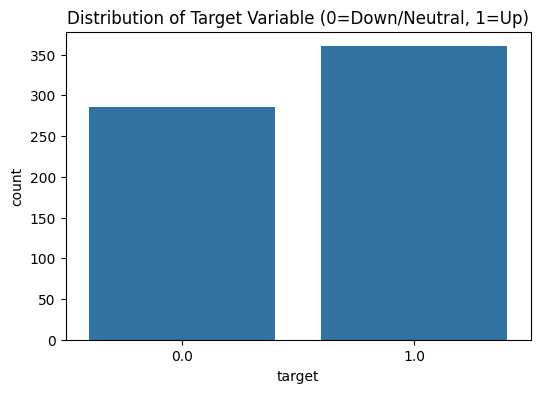

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=data)
plt.title('Distribution of Target Variable (0=Down/Neutral, 1=Up)')
plt.show()

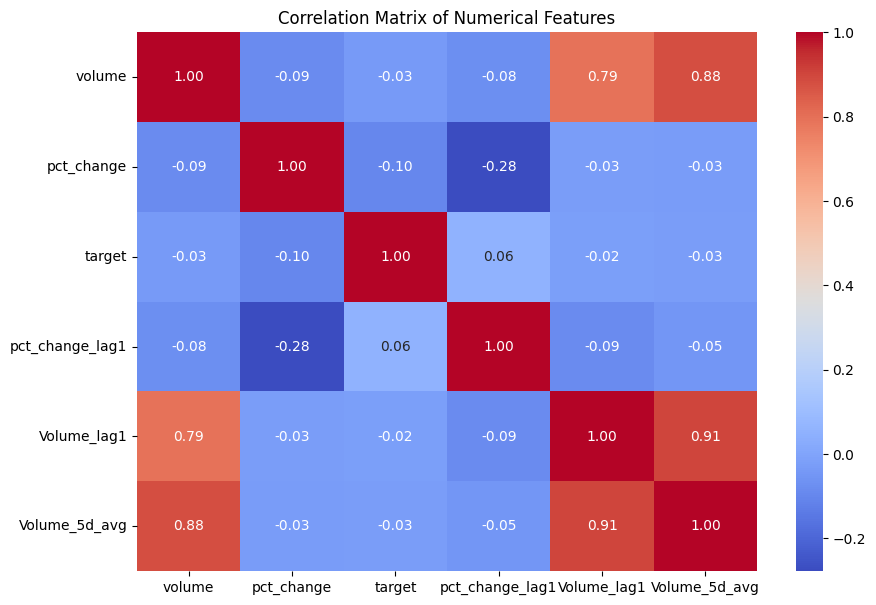

In [ ]:

numeric_cols = ['volume', 'pct_change', 'target',
                'pct_change_lag1', 'Volume_lag1', 'Volume_5d_avg']
plt.figure(figsize=(10, 7))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Good correlation between Volume 5 day average in todays volume meaning that the volumne carries out day to day. Meaning a high volume peak can lead to high volumes over the next 5 days

pct_change and pct_change_lag1 has negative correlation meaning that if today is up then tomorrow is most likely to be down and vise versa

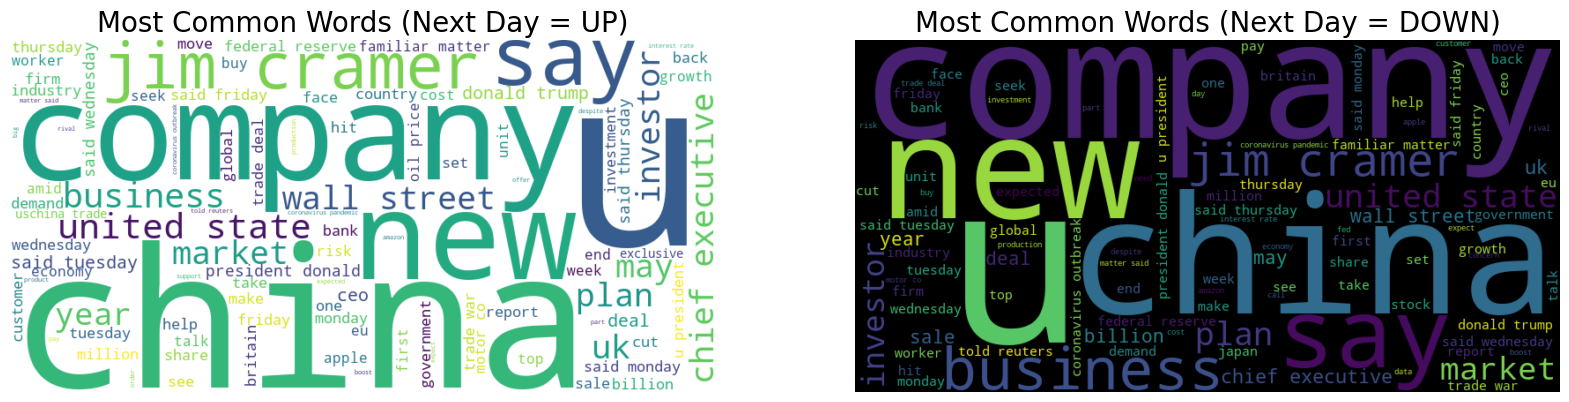

In [19]:
text_up = ' '.join(data[data['target']==1]['summary'])
text_down = ' '.join(data[data['target']==0]['summary'])

wordcloud_up = WordCloud(background_color='white', max_words=100, width=800, height=400).generate(text_up)
wordcloud_down = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(text_down)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
ax1.imshow(wordcloud_up, interpolation='bilinear')
ax1.set_title('Most Common Words (Next Day = UP)', fontsize=20)
ax1.axis('off')
ax2.imshow(wordcloud_down, interpolation='bilinear')
ax2.set_title('Most Common Words (Next Day = DOWN)', fontsize=20)
ax2.axis('off')
plt.show()

In [20]:
from collections import Counter
import re

# function to tokenize and clean words
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)   # remove punctuation/numbers
    return text.split()

# get text for target UP and DOWN
text_up = ' '.join(data[data['target'] == 1]['summary'])
text_down = ' '.join(data[data['target'] == 0]['summary'])

# tokenize
words_up = tokenize(text_up)
words_down = tokenize(text_down)

# count frequencies
freq_up = Counter(words_up)
freq_down = Counter(words_down)

# print top 10
print("\n🔺 Top 10 Words for Target = 1 (UP):")
print(freq_up.most_common(10))

print("\n🔻 Top 10 Words for Target = 0 (DOWN):")
print(freq_down.most_common(10))



🔺 Top 10 Words for Target = 1 (UP):
[('u', 10878), ('said', 7986), ('china', 4231), ('trade', 4104), ('company', 3786), ('new', 3476), ('billion', 3328), ('inc', 3217), ('say', 3153), ('market', 2993)]

🔻 Top 10 Words for Target = 0 (DOWN):
[('u', 8060), ('said', 6123), ('company', 3059), ('china', 2981), ('trade', 2970), ('coronavirus', 2713), ('inc', 2643), ('billion', 2623), ('new', 2608), ('say', 2428)]
